# Query Embedding-Space Visualisation

Projects each query's **plan-graph feature vector** (the same bag-of-features
representation the diversity metrics in `SQL_gen_analysis.ipynb` are built from --
operator-type counts, operator-pair/edge counts, operator 3-grams; see
`loader/workload_analysis.py:plan_graph_feature_counter`) into 2D, so the
structural diversity claims in Table 1 (plan-graph Vendi, uniqueness ratio, mean
NN distance) become something you can literally *see*.

**Methodology notes (read before citing a number from this notebook in the
paper):**
- Feature counts are **log1p-scaled** before PCA/UMAP. Raw counts are heavy-tailed
  (a handful of unusually large/complex queries can have counts an order of
  magnitude above the median), and without rescaling those queries alone define
  the top principal components / UMAP neighbourhoods -- diluting the actual
  structural-variety signal we care about.
- The primary, citable spread number is **mean weighted-Jaccard distance**
  computed directly on the feature Counters (`loader/workload_analysis.py:
  weighted_jaccard_similarity`) -- the *exact same similarity notion* behind
  Table 1's Vendi score and mean-NN-distance. It needs no projection and no
  hyperparameters, so it isn't sensitive to a UMAP seed or a PCA axis being
  dominated by outliers.
- The 2D scatter/contour plots are the **illustration** of that number, not a
  second, independent claim. Convex-hull area on a 2D projection is *not*
  reported as a headline metric here -- it's dominated by whichever single
  point happens to sit furthest from the crowd, which is a bad property for
  anything going in a paper.

Plans are cached to `results/embedding_records_cache.pkl` after the first live
run (each query needs one `EXPLAIN (FORMAT JSON)` round-trip against Trino, so
re-fetching per session is wasteful). Delete the cache file to force a fresh pull.

## 0 · Config

In [1]:
from pathlib import Path
from collections import Counter
from itertools import combinations
import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction import DictVectorizer
from sklearn.decomposition import PCA
from scipy.stats import gaussian_kde

from loader.workload_analysis import (
    dags_from_plan_bundle,
    plan_graph_feature_counter,
    weighted_jaccard_similarity,
)

try:
    import umap
    HAVE_UMAP = True
except ImportError:
    HAVE_UMAP = False

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "savefig.bbox": "tight",
    "font.size": 9, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5,
})

WORKLOAD_ROOT = Path("/mnt/primary/Main/Workloads")
CACHE_PATH = Path("results/embedding_records_cache.pkl")
CATALOG = "iceberg"
SCHEMA = "tpcds"
MAX_QUERIES_PER_WORKLOAD = 1000  # only matters on a cache miss -- EXPLAIN is a
                                  # live round-trip per query.

REF   = "tpcds"
OURS  = ["gpt_generated_1000_tpcds_tokens"]
BASELINES = ["bootstrapping_lcm_1000_tokens_tpcds",  # alphabetical by display name
             "e2etune_1000_tokens_tpcds",
             "sql_factory_1000_tokens_tpcds",
             "sqlbarber_1000_tokens_tpcds",
             "sqlstorm_1000_tokens_tpcds"]
WORKLOADS = [REF] + BASELINES + OURS

PRETTY = {"tpcds": "TPC-DS (ref)", "gpt_generated_1000_tpcds_tokens": "\\sys~(Ours)",
          "sqlstorm_1000_tokens_tpcds": "SQLStorm", "sqlbarber_1000_tokens_tpcds": "SQLBarber",
          "sql_factory_1000_tokens_tpcds": "SQL-Factory", "e2etune_1000_tokens_tpcds": "E2ETune",
          "bootstrapping_lcm_1000_tokens_tpcds": "Bootstrapping-LCM"}

# Distinct colour per baseline -- NOT a uniform grey -- so per-workload panels
# are actually legible; TPC-DS reference is always the same light-grey backdrop.
COL = {
    "tpcds": "#9ca3af",
    "bootstrapping_lcm_1000_tokens_tpcds": "#6366f1",  # indigo
    "e2etune_1000_tokens_tpcds":           "#059669",  # emerald
    "sql_factory_1000_tokens_tpcds":       "#0891b2",  # cyan
    "sqlbarber_1000_tokens_tpcds":         "#a855f7",  # violet
    "sqlstorm_1000_tokens_tpcds":          "#db2777",  # pink
    "gpt_generated_1000_tpcds_tokens":     "#ea580c",  # orange (ours)
}
REF_BACKDROP = "#d4d4d4"

## 1 · Load plan-graph features (cached or live)

Each query becomes a bag-of-features `Counter` (operator types, operator-pair
edges, operator 3-grams) via `plan_graph_feature_counter`. Cache hit skips Trino
entirely; cache miss connects to the live Lakehouse instance, pulls plans, and
writes the cache for next time.

In [2]:
if CACHE_PATH.exists():
    with open(CACHE_PATH, "rb") as f:
        _cache = pickle.load(f)
    records, failures = _cache["records"], _cache["failures"]
    print(f"loaded {len(records)} cached records from {CACHE_PATH} "
          f"(max_queries_per_workload={_cache.get('max_queries_per_workload')})")
else:
    from trino_stack.lakehouse import Lakehouse
    lh = Lakehouse.from_release(
        instance_name="lakehouse-g",
        namespace="pgr24james",
        sync_schemas=True,
        verbose=False,
    )

    records, failures = [], []
    for w in WORKLOADS:
        print(f"=== {w} ===")
        try:
            plan_bundle = lh.load_query_plans(
                workload_path=str(WORKLOAD_ROOT / w),
                schema=SCHEMA,
                max_queries=MAX_QUERIES_PER_WORKLOAD,
            )
            dags = dags_from_plan_bundle(plan_bundle)
            for qname, dag in dags.items():
                records.append({"workload": w, "query": qname,
                                 "features": plan_graph_feature_counter(dag)})
            print(f"  {len(dags)} query plans")
        except Exception as e:
            failures.append({"workload": w, "error": repr(e)})
            print(f"  FAILED: {e!r}")

    CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(CACHE_PATH, "wb") as f:
        pickle.dump({"records": records, "failures": failures,
                     "max_queries_per_workload": MAX_QUERIES_PER_WORKLOAD}, f)
    print(f"\ncached {len(records)} records -> {CACHE_PATH}")

if failures:
    print("failures:", failures)

meta = pd.DataFrame({"workload": [r["workload"] for r in records],
                      "query": [r["query"] for r in records]})
print(meta["workload"].value_counts().rename(index=PRETTY))

loaded 6099 cached records from results/embedding_records_cache.pkl (max_queries_per_workload=1000)
workload
Bootstrapping-LCM    1000
E2ETune              1000
SQL-Factory          1000
SQLBarber            1000
SQLStorm             1000
\sys~(Ours)          1000
TPC-DS (ref)           99
Name: count, dtype: int64


## 2 · Vectorize (log1p-scaled)

Pooled across *all* workloads into a single `DictVectorizer` so every query
lands in the same feature space. Counts are log1p-scaled -- without it, a
handful of unusually large/complex queries with abnormally high feature counts
would single-handedly define the top PCA axes / UMAP neighbourhoods.

In [3]:
vec = DictVectorizer(sparse=True)
# DictVectorizer wants str/num-keyed dicts; our Counter keys are tuples, so stringify.
feature_dicts = [{"|".join(map(str, k)): v for k, v in r["features"].items()} for r in records]
X_raw = vec.fit_transform(feature_dicts)

X = X_raw.copy()
X.data = np.log1p(X.data)  # scale down heavy-tailed counts; keeps sparsity

print(f"feature matrix: {X.shape[0]} queries x {X.shape[1]} features")

feature matrix: 6099 queries x 1729 features


## 3 · Pairwise plan-graph distance (weighted Jaccard)

The headline, citable spread number. Computed directly on the raw feature
`Counter`s -- not the log-scaled/vectorized matrix -- using the exact same
`weighted_jaccard_similarity` that Table 1's Vendi score and
mean-nearest-neighbour-distance are built from, so this number is consistent
with the rest of the paper's diversity claims. `O(n^2)` pairs; at ~6,000 pooled
queries that's ~18M pairwise evaluations -- slow (several minutes), but a
one-time cost that only needs re-running if the cached records change.

In [4]:
n = len(records)
counters = [r["features"] for r in records]
D = np.zeros((n, n), dtype=np.float32)  # distance = 1 - weighted Jaccard similarity

t0 = time.time()
total_pairs = n * (n - 1) // 2
for idx, (i, j) in enumerate(combinations(range(n), 2)):
    d = 1.0 - weighted_jaccard_similarity(counters[i], counters[j])
    D[i, j] = D[j, i] = d
    if idx % 500_000 == 0 and idx:
        elapsed = time.time() - t0
        print(f"  {idx:,}/{total_pairs:,} pairs ({elapsed:.0f}s elapsed, "
              f"~{elapsed / idx * total_pairs:.0f}s total est.)")

print(f"pairwise distance matrix done in {time.time() - t0:.0f}s")

  500,000/18,595,851 pairs (12s elapsed, ~452s total est.)
  1,000,000/18,595,851 pairs (24s elapsed, ~447s total est.)
  1,500,000/18,595,851 pairs (36s elapsed, ~444s total est.)
  2,000,000/18,595,851 pairs (48s elapsed, ~449s total est.)
  2,500,000/18,595,851 pairs (60s elapsed, ~448s total est.)
  3,000,000/18,595,851 pairs (72s elapsed, ~448s total est.)
  3,500,000/18,595,851 pairs (85s elapsed, ~449s total est.)
  4,000,000/18,595,851 pairs (97s elapsed, ~449s total est.)
  4,500,000/18,595,851 pairs (108s elapsed, ~448s total est.)
  5,000,000/18,595,851 pairs (121s elapsed, ~449s total est.)
  5,500,000/18,595,851 pairs (133s elapsed, ~448s total est.)
  6,000,000/18,595,851 pairs (144s elapsed, ~448s total est.)
  6,500,000/18,595,851 pairs (156s elapsed, ~447s total est.)
  7,000,000/18,595,851 pairs (169s elapsed, ~448s total est.)
  7,500,000/18,595,851 pairs (181s elapsed, ~449s total est.)
  8,000,000/18,595,851 pairs (193s elapsed, ~450s total est.)
  8,500,000/18,595

## 4 · Project to 2D

Two views: **UMAP on the precomputed weighted-Jaccard distance matrix** (the
primary, methodologically-consistent view -- same similarity notion as Table 1)
and **PCA on the log1p-scaled feature matrix** (a linear sanity check). Explicit
`init="random"` on UMAP avoids a silent, seed-sensitive fallback if spectral
initialisation fails on sparse/near-disconnected regions of the feature space.

In [5]:
pca = PCA(n_components=2, random_state=0)
coords_pca = pca.fit_transform(X.toarray())
meta["pca_x"], meta["pca_y"] = coords_pca[:, 0], coords_pca[:, 1]
print(f"PCA explained variance (top 2): {pca.explained_variance_ratio_[:2].sum():.1%}")

if HAVE_UMAP:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="precomputed",
                         init="random", random_state=0)
    coords_umap = reducer.fit_transform(D)
    meta["umap_x"], meta["umap_y"] = coords_umap[:, 0], coords_umap[:, 1]
else:
    print("umap-learn not installed -- skipping UMAP, PCA panel only")

PCA explained variance (top 2): 31.4%


/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/miniconda3/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


## 5 · Per-workload footprint (small multiples)

One panel per workload, all sharing identical axis limits so footprints are
visually comparable; TPC-DS is a fixed light-grey backdrop in every panel for a
shared frame of reference. Density contours (not raw hull outlines) show where
each workload's mass actually sits -- robust to the odd outlier query, unlike a
convex hull. The panel title reports the headline **mean weighted-Jaccard
distance** from §3 (citable), not hull area (not citable -- see the intro).

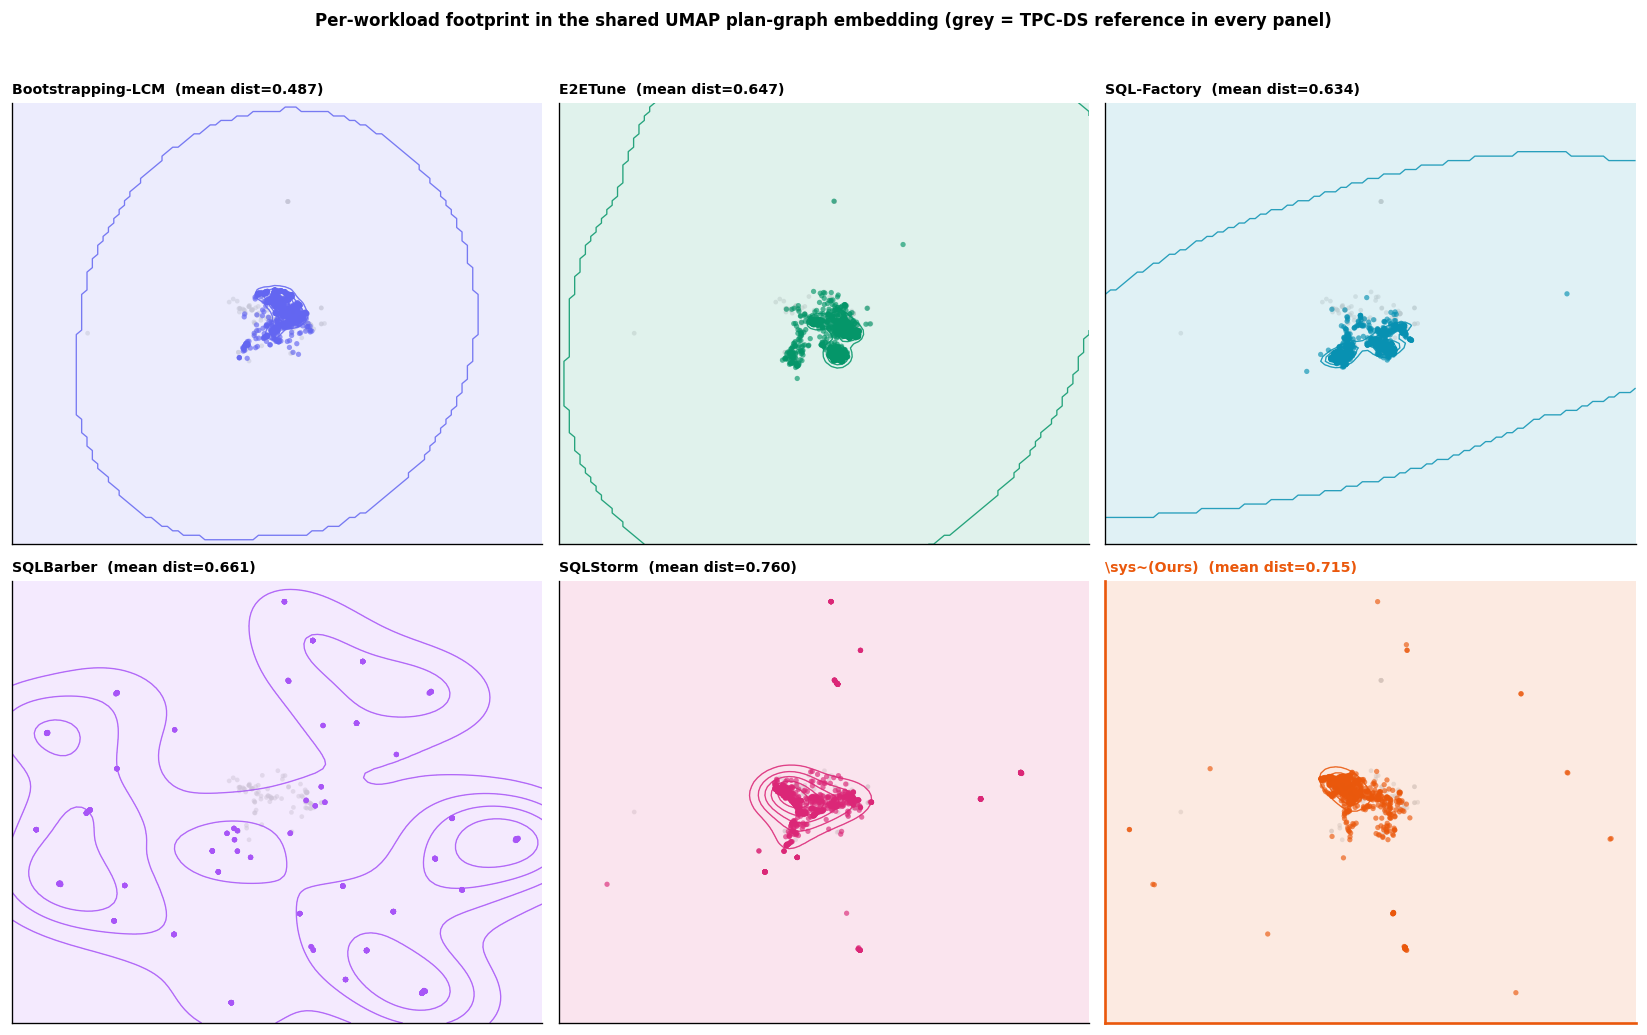

In [6]:
EMBED = "umap" if HAVE_UMAP else "pca"
xcol, ycol = f"{EMBED}_x", f"{EMBED}_y"

pad = 0.05
x_lo, x_hi = meta[xcol].min(), meta[xcol].max()
y_lo, y_hi = meta[ycol].min(), meta[ycol].max()
x_pad, y_pad = (x_hi - x_lo) * pad, (y_hi - y_lo) * pad
xlim = (x_lo - x_pad, x_hi + x_pad)
ylim = (y_lo - y_pad, y_hi + y_pad)

ref_pts = meta[meta["workload"] == REF][[xcol, ycol]].to_numpy()
workload_idx = {w: [i for i, r in enumerate(records) if r["workload"] == w] for w in WORKLOADS}

def mean_feature_space_distance(w):
    idx = workload_idx[w]
    if len(idx) < 2:
        return np.nan
    sub = D[np.ix_(idx, idx)]
    iu = np.triu_indices(len(idx), k=1)
    return float(sub[iu].mean())

def kde_contours(ax, xy, color):
    xy = np.asarray(xy)
    if len(xy) < 5:
        return
    try:
        kde = gaussian_kde(xy.T)
    except np.linalg.LinAlgError:
        return  # degenerate (near-collinear) point set; skip contours, keep scatter
    gx, gy = np.mgrid[xlim[0]:xlim[1]:100j, ylim[0]:ylim[1]:100j]
    density = kde(np.vstack([gx.ravel(), gy.ravel()])).reshape(gx.shape)
    ax.contour(gx, gy, density, levels=5, colors=color, linewidths=0.8, alpha=0.85)
    ax.contourf(gx, gy, density, levels=5, colors=[color], alpha=0.12)

panel_order = BASELINES + OURS  # TPC-DS is the shared backdrop, not its own panel
ncols = 3
nrows = -(-len(panel_order) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, w in zip(axes, panel_order):
    sub = meta[meta["workload"] == w]
    xy = sub[[xcol, ycol]].to_numpy()

    ax.scatter(ref_pts[:, 0], ref_pts[:, 1], s=8, color=REF_BACKDROP, alpha=0.5,
               edgecolor="none", zorder=1, label=PRETTY[REF])
    kde_contours(ax, xy, COL[w])
    ax.scatter(xy[:, 0], xy[:, 1], s=10, color=COL[w], alpha=0.65,
               edgecolor="none", zorder=3)

    spread = mean_feature_space_distance(w)
    ax.set_title(f"{PRETTY[w]}  (mean dist={spread:.3f})", fontsize=8.5,
                 fontweight="bold", loc="left", color=COL[w] if w in OURS else "black")
    if w in OURS:
        for spine in ax.spines.values():
            spine.set_edgecolor(COL[w]); spine.set_linewidth(1.6)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(alpha=0.1)

for ax in axes[len(panel_order):]:
    ax.axis("off")

fig.suptitle(f"Per-workload footprint in the shared {EMBED.upper()} plan-graph embedding "
             f"(grey = TPC-DS reference in every panel)",
             fontsize=10, fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

## 6 · Quantitative companion table

**Mean feature-space distance** (weighted-Jaccard, no projection involved) is
the number to cite -- it's the same similarity notion behind Table 1 and isn't
sensitive to a UMAP seed or an outlier query. The embedding-space mean pairwise
distance is included only as a sanity check that the 2D picture agrees with the
underlying feature-space number.

In [7]:
from scipy.spatial.distance import pdist

def mean_pairwise_spread(xy):
    if len(xy) < 2:
        return np.nan
    return float(pdist(xy).mean())

rows = []
for w in WORKLOADS:
    sub = meta[meta["workload"] == w]
    rows.append({
        "workload": PRETTY[w],
        "n_queries": len(sub),
        "Mean feature-space distance (cite this)": mean_feature_space_distance(w),
        f"Mean {EMBED.upper()} distance (sanity check)": mean_pairwise_spread(sub[[xcol, ycol]].to_numpy()),
    })

pd.DataFrame(rows).set_index("workload")

,n_queries,Mean feature-space distance (cite this),Mean UMAP distance (sanity check)
workload,,,
TPC-DS (ref),99,0.656712,5.350084
Bootstrapping-LCM,1000,0.487105,2.718401
E2ETune,1000,0.647365,3.397949
SQL-Factory,1000,0.633634,3.480917
SQLBarber,1000,0.661110,26.126304
SQLStorm,1000,0.760183,8.682356
\sys~(Ours),1000,0.715075,4.239025


## 7 · Nearest-neighbour spacing profile — does the mean hide duplicates?

The §6 mean feature-space distance is an average over **all** pairs, so it can't tell
you *where* the mass sits. A workload can post a high mean while a chunk of its
queries collapse onto near-duplicate plans, as long as the rest are spread far
enough apart to pull the average back up — the all-pairs mean has no concept of
local density. That's exactly the profile SQLStorm shows: its plan-graph uniqueness
ratio is 0.790 (Table 1) yet its mean feature-space distance (0.760) is the highest
of any workload, including ours (0.715).

The fix is to look at the **distribution of each query's distance to its single
closest neighbour**, sorted ascending, rather than the one-number average.
A generator that guarantees separation shows a curve that lifts off from zero
immediately; a generator with hidden duplication shows a flat near-zero shelf on
the low end before the curve rises. This is the same notion Table 1's
`mean_nearest_neighbour_distance` already uses — this plot is its full distribution,
not just the mean.

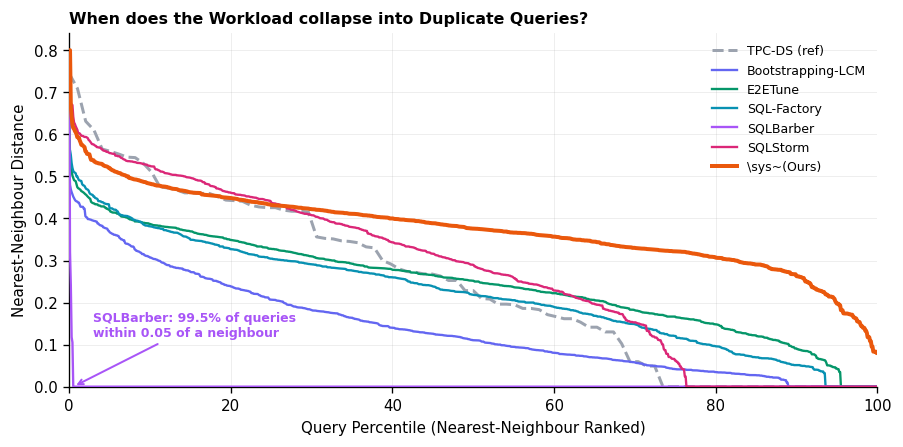

,Share of queries within 0.05 of a neighbour
SQLBarber,99.5%
TPC-DS (ref),29.3%
Bootstrapping-LCM,27.8%
SQLStorm,24.5%
SQL-Factory,9.4%
E2ETune,5.8%
\sys~(Ours),0.0%


In [44]:
def within_workload_nn_distances(w):
    """Each query's distance to its closest *other* query in the same workload."""
    idx = workload_idx[w]
    if len(idx) < 2:
        return np.array([])
    sub = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(sub, np.inf)
    return sub.min(axis=1)

EPS = 0.05  # "near-duplicate" threshold on weighted-Jaccard plan-graph distance

fig, ax = plt.subplots(figsize=(7.6, 3.8))


dup_rates = {}
nn_sorted_by_workload = {}
for w in WORKLOADS:
    nn = within_workload_nn_distances(w)
    if len(nn) == 0:
        continue
    # Sorted DESCENDING: x=0 (left) is each workload's most-isolated query,
    # x=100 (right) is its most-redundant one. 
    nn_sorted = np.sort(nn)[::-1]
    pct = np.linspace(0, 100, len(nn_sorted))
    lw = 2.4 if w in OURS else (1.8 if w == REF else 1.4)
    ls = "--" if w == REF else "-"
    zorder = 5 if w in OURS else 3
    ax.plot(pct, nn_sorted, color=COL[w], lw=lw, ls=ls, zorder=zorder, label=PRETTY[w])
    dup_rates[w] = float((nn_sorted < EPS).mean())
    nn_sorted_by_workload[w] = nn_sorted

# Call out SQLBarber specifically: its collapse is so fast (>99% of queries
# land within EPS of a neighbour) that it happens in the first ~1% of the
# x-axis -- easy to misread as "starts near zero" instead of "instantly
# collapses" unless it's flagged directly.
SQLBARBER = "sqlbarber_1000_tokens_tpcds"
nn_sb = nn_sorted_by_workload[SQLBARBER]
pct_sb = np.linspace(0, 100, len(nn_sb))
cliff_i = int(np.argmax(nn_sb < EPS))  # first point that's dropped into near-duplicate territory
ax.annotate(
    f"SQLBarber: {dup_rates[SQLBARBER]:.1%} of queries\nwithin {EPS} of a neighbour",
    xy=(pct_sb[cliff_i], nn_sb[cliff_i]), xycoords="data",
    xytext=(3, 0.12), textcoords="data",
    fontsize=7.5, fontweight="bold", color=COL[SQLBARBER],
    arrowprops=dict(arrowstyle="->", color=COL[SQLBARBER], lw=1.2,
                     connectionstyle="arc3,rad=-0"),
)

ax.set_xlabel("Query Percentile (Nearest-Neighbour Ranked)")
ax.set_ylabel("Nearest-Neighbour Distance")
ax.set_title("When does the Workload collapse into Duplicate Queries?",
             loc="left", fontsize=9.5, fontweight="bold")
ax.set_xlim(0, 100); ax.set_ylim(bottom=0)
ax.legend(fontsize=7.5, loc="upper right", frameon=False)
plt.tight_layout(); plt.show()

(pd.Series(dup_rates, name="pct")
   .rename(index=PRETTY)
   .sort_values(ascending=False)
   .to_frame(f"Share of queries within {EPS} of a neighbour")
   .style.format("{:.1%}"))

## 8 · Where the redundancy hides in the embedding

Same panel layout as §5, but each point is now coloured by its own within-workload
nearest-neighbour distance (dark = has a near-duplicate sitting right next to it,
light = well separated) instead of a flat per-workload colour. A workload that
relies on a handful of far-apart templates instantiated many times shows up as
dark, saturated **clumps** — visible clustering, not just a summary statistic.
A workload with a genuine separation guarantee stays uniformly light across its
whole footprint. This is the visual counterpart to the spacing-profile curve in §7,
localised back onto the plan-graph geometry from §5.

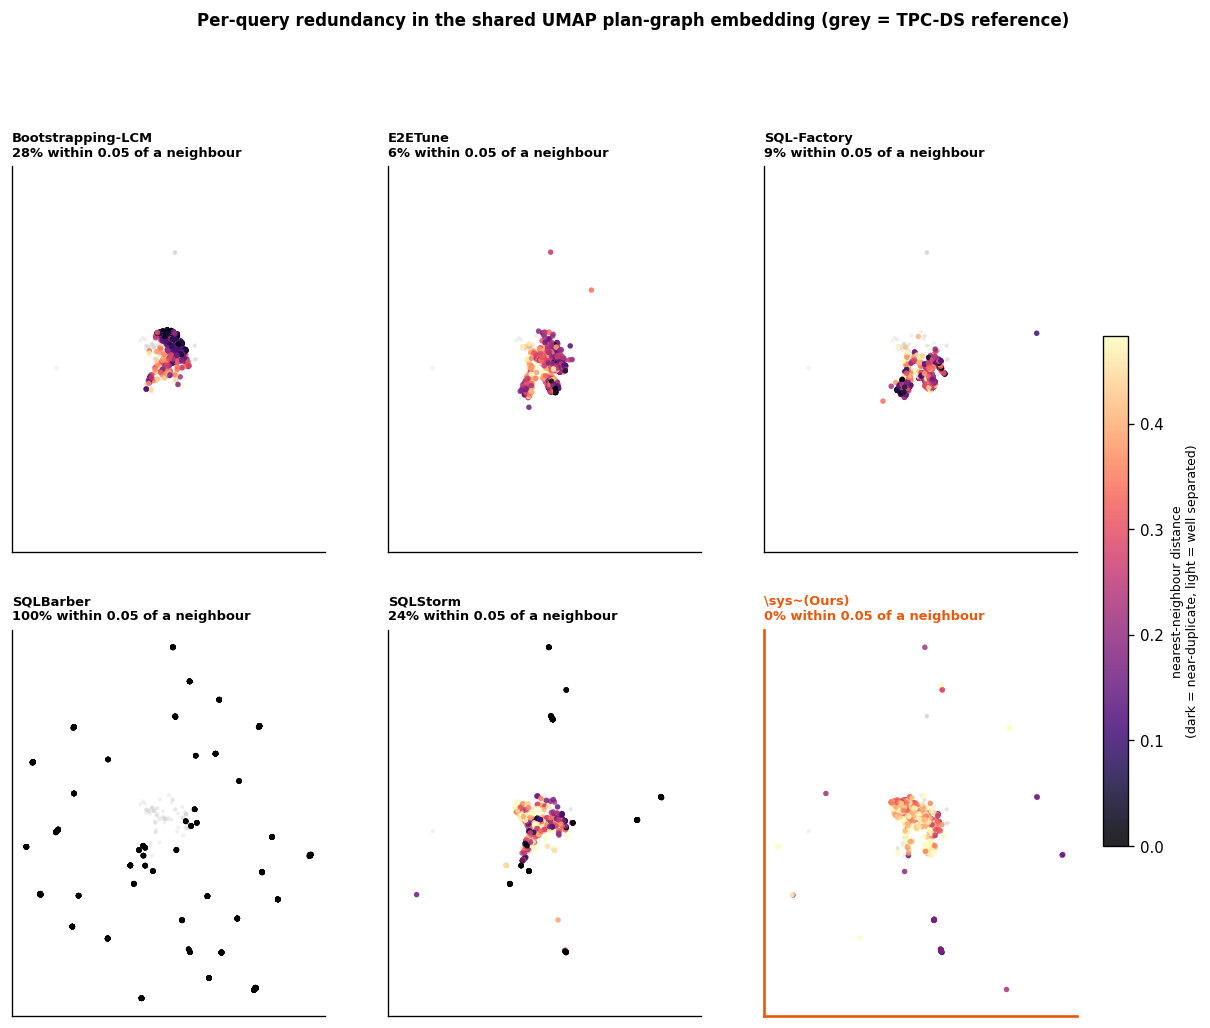

In [10]:
nn_all = np.full(len(records), np.nan)
for w in WORKLOADS:
    idx = workload_idx[w]
    if len(idx) < 2:
        continue
    sub = D[np.ix_(idx, idx)].copy()
    np.fill_diagonal(sub, np.inf)
    nn_all[idx] = sub.min(axis=1)
meta["nn_distance"] = nn_all

# clip the colour scale at the 95th percentile so a handful of extreme-outlier
# queries don't wash out the (much more common) low end that we care about here
vmin, vmax = 0.0, float(np.nanpercentile(nn_all, 95))

fig, axes = plt.subplots(nrows, ncols, figsize=(4.6 * ncols, 4.6 * nrows))
axes = np.atleast_1d(axes).ravel()
sm = None
for ax, w in zip(axes, panel_order):
    sub = meta[meta["workload"] == w]
    xy = sub[[xcol, ycol]].to_numpy()
    c = sub["nn_distance"].to_numpy()

    ax.scatter(ref_pts[:, 0], ref_pts[:, 1], s=6, color=REF_BACKDROP, alpha=0.35,
               edgecolor="none", zorder=1)
    # cmap="magma" (NOT magma_r): low distance (duplicate) -> black, high -> pale
    # yellow, matching the "dark = near-duplicate" colourbar label below.
    sm = ax.scatter(xy[:, 0], xy[:, 1], c=c, cmap="magma", vmin=vmin, vmax=vmax,
                     s=11, alpha=0.85, edgecolor="none", zorder=3)

    dup_share = float((c < EPS).mean())
    ax.set_title(f"{PRETTY[w]}\n{dup_share:.0%} within {EPS} of a neighbour",
                 fontsize=7.8, fontweight="bold", loc="left",
                 color=COL[w] if w in OURS else "black")
    if w in OURS:
        for spine in ax.spines.values():
            spine.set_edgecolor(COL[w]); spine.set_linewidth(1.6)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_xticks([]); ax.set_yticks([])
    ax.grid(alpha=0.1)

for ax in axes[len(panel_order):]:
    ax.axis("off")

cbar = fig.colorbar(sm, ax=axes[:len(panel_order)], shrink=0.6, pad=0.02)
cbar.set_label("nearest-neighbour distance\n(dark = near-duplicate, light = well separated)",
               fontsize=7.5)

fig.suptitle(f"Per-query redundancy in the shared {EMBED.upper()} plan-graph embedding "
             f"(grey = TPC-DS reference)", fontsize=10, fontweight="bold", y=1.02)
plt.show()